In [1]:
import BiSSGL as BiSSGL
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit
import matplotlib.pyplot as plt
import seaborn as sns  # optional, for nicer heatmaps


def plot_matrices(U, V):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    sns.heatmap(U, ax=axes[0], cmap="viridis", cbar=True)
    axes[0].set_title("Latent Matrix U")

    sns.heatmap(V, ax=axes[1], cmap="viridis", cbar=True)
    axes[1].set_title("Latent Matrix V")

    plt.tight_layout()
    plt.show()

In [2]:
# This is new simulation setting for the feature selection:
I = 80
J = 160
d = d1 = d2 = 20
K = K1 = K2 = 10

U = np.random.normal(0, np.sqrt(0.05), size=(I, d1))
U_true = U[:, :K1]
V = np.random.normal(0, np.sqrt(0.05), size=(J, d2))
V_true = V[:, :K2]
A_true = np.eye(K1)
B_true = np.eye(K2)

Pr = expit(U_true @ A_true @ B_true.T @ V_true.T)
Y_true = (Pr > 0.55).astype(int)

sparsity = 0.01
index = np.array(np.meshgrid(np.arange(I), np.arange(J))).T.reshape(-1, 2)
masked_indices = index[
    np.random.choice(index.shape[0], size=int((1 - sparsity) * I * J), replace=False)
]
Y_masked = Y_true[masked_indices[:, 0], masked_indices[:, 1]]
Y = Y_true.copy()
Y[masked_indices[:, 0], masked_indices[:, 1]] = 0

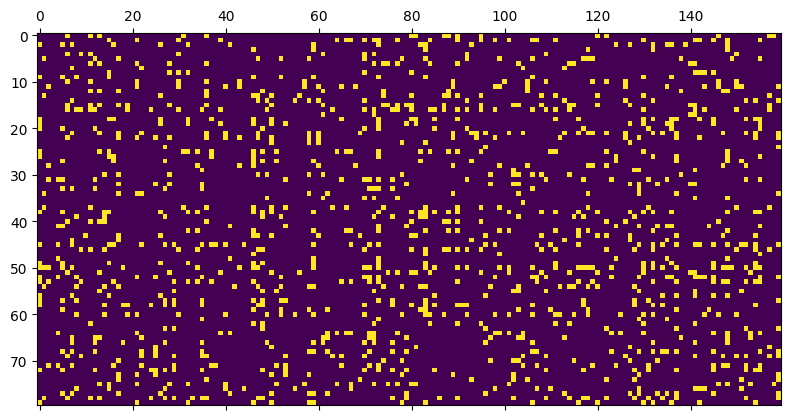

In [3]:
plt.matshow(Y_true)

In [2]:
# This is new simulation setting for the feature selection:
I = 80
J = 160
d = d1 = d2 = 10
K = K1 = K2 = 3

U = np.random.normal(0, np.sqrt(0.01), size=(I, d1))
U_true = U[:, :K1]
V = np.random.normal(0, np.sqrt(0.01), size=(J, d2))
V_true = V[:, :K2]
A_true = np.ones((K, K))
B_true = np.ones((K, K))

Pr = expit(U_true @ A_true @ B_true.T @ V_true.T)
Y_true = (Pr > 0.5).astype(int)

sparsity = 0.01
index = np.array(np.meshgrid(np.arange(I), np.arange(J))).T.reshape(-1, 2)
masked_indices = index[
    np.random.choice(index.shape[0], size=int((1 - sparsity) * I * J), replace=False)
]
Y_masked = Y_true[masked_indices[:, 0], masked_indices[:, 1]]
Y = Y_true.copy()
Y[masked_indices[:, 0], masked_indices[:, 1]] = 0

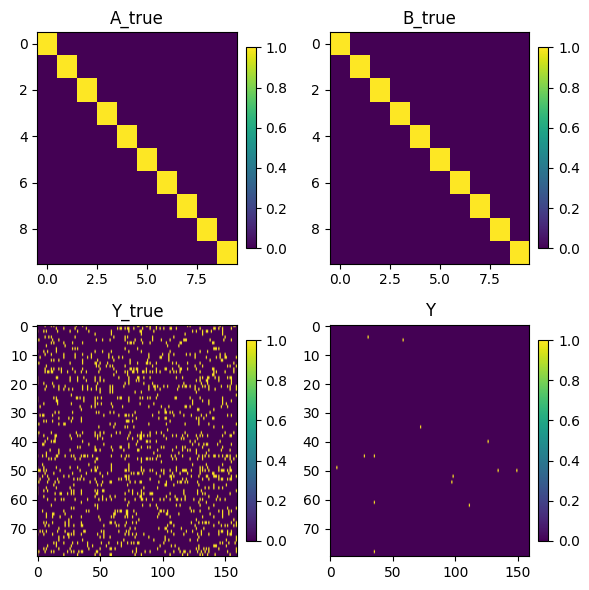

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))

axes[0, 0].imshow(A_true, aspect="auto", cmap="viridis")
axes[0, 0].set_title("A_true")
plt.colorbar(axes[0, 0].images[0], ax=axes[0, 0], fraction=0.046, pad=0.04)

axes[0, 1].imshow(B_true, aspect="auto", cmap="viridis")
axes[0, 1].set_title("B_true")
plt.colorbar(axes[0, 1].images[0], ax=axes[0, 1], fraction=0.046, pad=0.04)

axes[1, 0].imshow(Y_true, aspect="auto", cmap="viridis")
axes[1, 0].set_title("Y_true")
plt.colorbar(axes[1, 0].images[0], ax=axes[1, 0], fraction=0.046, pad=0.04)

axes[1, 1].imshow(Y, aspect="auto", cmap="viridis")
axes[1, 1].set_title("Y")
plt.colorbar(axes[1, 1].images[0], ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [5]:
# U.shape, V.shape, A_true.shape
A = np.zeros((d1, K))
A[range(K), range(K)] = 1
A[K:] = np.random.normal(size=A[K:].shape) / 10
Ainput = A.copy()

B = np.zeros((d2, K))
B[range(K), range(K)] = 1
B[K:] = np.random.normal(size=B[K:].shape) / 10
Binput = B.copy()

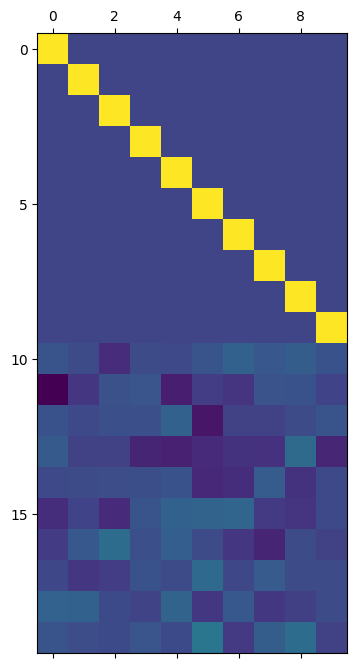

In [6]:
plt.matshow(Ainput)
# print(Ainput)

In [11]:
est_mu, est_A, est_B, logLik = BiSSGL.optimization(
    Y_true,
    U=U,
    V=V,
    xi=1,
    eta=0.001,
    tilde_lambda0=5,
    tilde_lambda1=1,
    tilde_alpha=1,
    tilde_beta=1,
    lambda0=5,
    lambda1=1,
    alpha=1,
    beta=1,
    K=10,
    max_iter=200,
    tol=1e-5,
    A=Ainput,
    B=Binput,
)

[-31.50943323  22.56405241   7.97607311   6.31227679   1.36995136
   4.21653154  -7.24375283  -2.95762135   6.70630257   9.62868768]
[-34.09529486   9.74754307  -3.51809049   7.6231821    2.52418478
   1.05792549 -12.66018443   7.43422357   3.44079191  -6.39856607]
[-30.96208184  22.03382327   7.85309586   6.15636771   1.39670587
   4.07841233  -7.16739143  -2.92202814   6.5522365    9.42070568]
[-35.01939     10.38938486  -3.29398043   7.89982458   2.68903319
   1.46417705 -12.55755443   7.41274513   3.37103452  -5.9504043 ]
[-32.39739674  22.35260007   7.48422146   6.23659684   1.09299098
   3.88267918  -7.61199965  -2.58333957   7.1349342    9.9509939 ]
[-35.79941586  10.91432142  -3.04188897   8.15054151   2.87301375
   1.88167641 -12.35080807   7.31055206   3.2029035   -5.48212026]
[-33.70751929  22.47176814   7.09852267   6.33600693   0.82927504
   3.64013313  -8.02158909  -2.19921096   7.65239438  10.45670261]
[-36.30822614  11.16849495  -2.80939327   8.36188205   3.089515
   2.

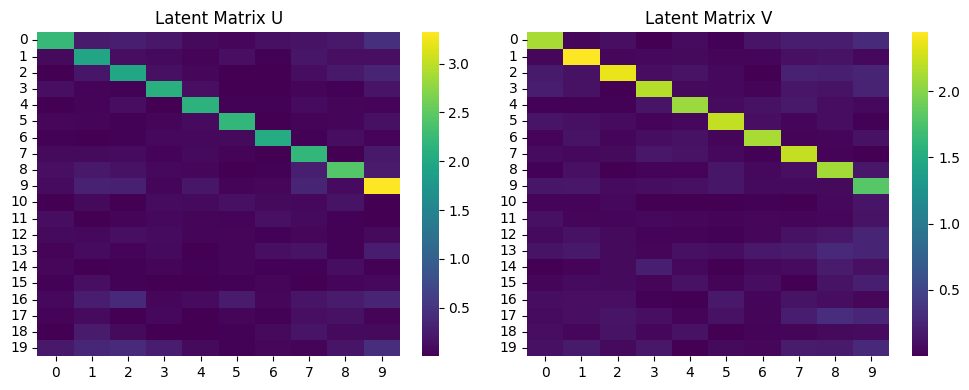

In [12]:
plot_matrices(np.abs(est_A), np.abs(est_B))

In [15]:
np.abs(est_A)

array([[2.22589420e+00, 2.37785563e-01, 2.78023156e-01, 1.98141202e-01,
        7.97817225e-02, 6.46168997e-02, 1.36144812e-01, 1.59986583e-01,
        2.10263935e-01, 4.62027150e-01],
       [7.88078963e-02, 1.95025071e+00, 1.10332329e-01, 8.93217900e-02,
        3.00190180e-02, 1.18201506e-01, 1.83929980e-02, 1.92279557e-01,
        1.20356158e-01, 1.25193264e-01],
       [1.71994370e-03, 1.87141062e-01, 1.97720130e+00, 1.39222830e-01,
        5.44577651e-02, 5.27846130e-03, 2.30972842e-03, 1.06688378e-01,
        2.20383104e-01, 3.25496721e-01],
       [1.27833826e-01, 3.27390648e-02, 2.07287569e-02, 2.10673125e+00,
        1.17612511e-01, 4.55070660e-03, 9.22132141e-03, 5.16311341e-02,
        1.60460575e-02, 1.71401889e-01],
       [1.19777835e-02, 3.24966040e-02, 1.06074874e-01, 8.29152074e-04,
        2.13244844e+00, 1.60393891e-02, 1.59549189e-02, 9.40158075e-02,
        4.47473935e-02, 3.86502328e-02],
       [5.33140463e-02, 4.30075233e-02, 1.40513596e-02, 4.87977257e-02,
   

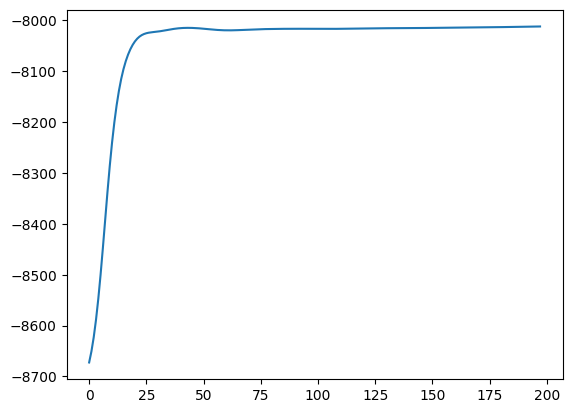

In [14]:
plt.plot(range(len(logLik)), logLik)

In [13]:
logLik

[np.float64(-8941.809558823017),
 np.float64(-8941.855389924314),
 np.float64(-8941.912686243857),
 np.float64(-8941.981454258937),
 np.float64(-8942.061700850263),
 np.float64(-8942.153433882488),
 np.float64(-8942.256662278984),
 np.float64(-8942.371396040755),
 np.float64(-8942.4976462544),
 np.float64(-8942.36267815136),
 np.float64(-8942.511164688456),
 np.float64(-8942.671154479958),
 np.float64(-8942.842660284623),
 np.float64(-8943.025696808369),
 np.float64(-8943.22028039035),
 np.float64(-8943.426428820712),
 np.float64(-8943.644161231623),
 np.float64(-8943.873498030865),
 np.float64(-8944.114460861156),
 np.float64(-8944.367072575442),
 np.float64(-8944.631357222564),
 np.float64(-8944.90734003978),
 np.float64(-8945.195047449948),
 np.float64(-8945.494507062062),
 np.float64(-8945.805747674165),
 np.float64(-8946.128799278084),
 np.float64(-8946.463693065536),
 np.float64(-8946.810461435383),
 np.float64(-8947.169138001782),
 np.float64(-8947.539757603156),
 np.float64(-89